<a href="https://colab.research.google.com/github/Subuktageen-Farooqi/ms_course_deeplearning/blob/main/ms_deeplearning_tutorial_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1 : Importing Required Libraries

In [4]:
# Step 1 — Importing Required Libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

Step 2 : Loading and Splitting the Dataset

In [5]:
# Loading the iris dataset
data = load_iris()
X = data.data
y = data.target
# splitting data into 70% training 30% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Step 3 : Data Scaling

In [6]:
# standardize dataset to have Mean 0 and Variance 1
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Step 4 : Creating and Training the MLP Classifier

In [7]:
mlp = MLPClassifier(
    hidden_layer_sizes=(10, 10), max_iter=1000, random_state=42, learning_rate_init=0.001)

mlp.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(10, 10), max_iter=1000, random_state=42)

Step 5 : Making Predictions and Evaluating the Model

In [5]:
predictions = mlp.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print(f'Accuracy: {accuracy:.2f}')
print("Classification report:\n", classification_report(y_test, predictions))

Accuracy: 1.00
Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



Step 6 : Displaying the MLP Structure and Training
Information

In [6]:
print("\nMLP Structure:")
print(f"Number of Layers: {mlp.n_layers_}")
print(f"Number of Outputs: {mlp.n_outputs_}")
print(f"Activation Function: {mlp.activation}")
print(f"Output Activation Function: {mlp.out_activation_}")
print(f"Number of Epochs: {mlp.n_iter_}")



MLP Structure:
Number of Layers: 4
Number of Outputs: 3
Activation Function: relu
Output Activation Function: softmax
Number of Epochs: 609


Step 7 : Visualizing the Learning Curve

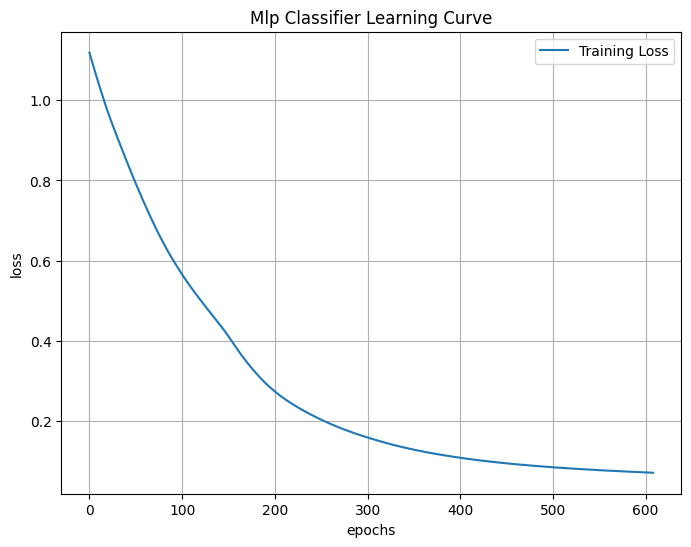

In [7]:
plt.figure(figsize=(8,6))
plt.plot(mlp.loss_curve_, label='Training Loss')
plt.title('Mlp Classifier Learning Curve')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.grid()
plt.show()

# Task 01 : Modify the MLP model to have different numbers of hidden layers and neurons

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

all_experiments = []

def run_single_experiment(
    exp_no,
    hidden_layers,
    learning_rate,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    max_iter=500,
    random_state=42
):
    clf = MLPClassifier(
        hidden_layer_sizes=hidden_layers,
        learning_rate_init=learning_rate,
        max_iter=max_iter,
        random_state=random_state
    )

    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)

    result = {
        "experiment_no": exp_no,
        "hidden_layers": str(hidden_layers),
        "learning_rate": learning_rate,
        "accuracy": acc,
        "epochs": clf.n_iter_,
        "final_loss": clf.loss_curve_[-1],
        "loss_curve": clf.loss_curve_,
        "model": clf
    }

    all_experiments.append(result)
    return result

def run_user_experiments(X_train_scaled, X_test_scaled, y_train, y_test):
    global all_experiments
    all_experiments = []

    n = int(input("How many experiments do you want to run? "))

    for i in range(1, n + 1):
        print(f"\n--- Experiment {i} ---")

        layer_input = input(
            "Enter hidden layer sizes separated by commas (example: 10,10 or 50 or 20,10,5): "
        ).strip()
        hidden_layers = tuple(int(x.strip()) for x in layer_input.split(","))

        learning_rate = float(input("Enter learning rate (example: 0.001): ").strip())
        max_iter_in = input("Enter max_iter (press Enter for 500): ").strip()
        max_iter = int(max_iter_in) if max_iter_in else 500

        run_single_experiment(
            exp_no=i,
            hidden_layers=hidden_layers,
            learning_rate=learning_rate,
            X_train_scaled=X_train_scaled,
            X_test_scaled=X_test_scaled,
            y_train=y_train,
            y_test=y_test,
            max_iter=max_iter
        )

    display_experiment_table()
    plot_all_loss_curves()

def display_experiment_table():
    if not all_experiments:
        print("No experiments found.")
        return

    rows = []
    for exp in all_experiments:
        rows.append({
            "Experiment": exp["experiment_no"],
            "Hidden Layers": exp["hidden_layers"],
            "Learning Rate": exp["learning_rate"],
            "Accuracy": round(exp["accuracy"], 4),
            "Epochs": exp["epochs"],
            "Final Loss": round(exp["final_loss"], 6),
        })

    df = pd.DataFrame(rows)
    df = df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
    print("\nExperiment Results Table")
    print(df.to_string(index=False))
    return df

def plot_all_loss_curves():
    if not all_experiments:
        print("No experiments found.")
        return

    plt.figure(figsize=(10, 6))

    for exp in all_experiments:
        plt.plot(
            exp["loss_curve"],
            label=f"Exp {exp['experiment_no']}: {exp['hidden_layers']}, lr={exp['learning_rate']}"
        )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss Curves for All Experiments")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

How many experiments do you want to run? 6

--- Experiment 1 ---
Enter hidden layer sizes separated by commas (example: 10,10 or 50 or 20,10,5): 50
Enter learning rate (example: 0.001): 0.001
Enter max_iter (press Enter for 500): 500


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(



--- Experiment 2 ---
Enter hidden layer sizes separated by commas (example: 10,10 or 50 or 20,10,5): 50, 50
Enter learning rate (example: 0.001): 0.001
Enter max_iter (press Enter for 500): 500

--- Experiment 3 ---
Enter hidden layer sizes separated by commas (example: 10,10 or 50 or 20,10,5): 50, 50, 50
Enter learning rate (example: 0.001): 0.001
Enter max_iter (press Enter for 500): 500

--- Experiment 4 ---
Enter hidden layer sizes separated by commas (example: 10,10 or 50 or 20,10,5): 100, 50, 25
Enter learning rate (example: 0.001): 0.001
Enter max_iter (press Enter for 500): 500

--- Experiment 5 ---
Enter hidden layer sizes separated by commas (example: 10,10 or 50 or 20,10,5): 75, 15, 3
Enter learning rate (example: 0.001): 0.001
Enter max_iter (press Enter for 500): 500


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(



--- Experiment 6 ---
Enter hidden layer sizes separated by commas (example: 10,10 or 50 or 20,10,5): 50, 30, 10
Enter learning rate (example: 0.001): 0.001
Enter max_iter (press Enter for 500): 500

Experiment Results Table
 Experiment Hidden Layers  Learning Rate  Accuracy  Epochs  Final Loss
          1         (50,)          0.001    1.0000     500    0.114365
          2      (50, 50)          0.001    1.0000     330    0.069873
          3  (50, 50, 50)          0.001    1.0000     211    0.066443
          4 (100, 50, 25)          0.001    1.0000     216    0.067982
          6  (50, 30, 10)          0.001    1.0000     342    0.071127
          5   (75, 15, 3)          0.001    0.5556     500    0.615562


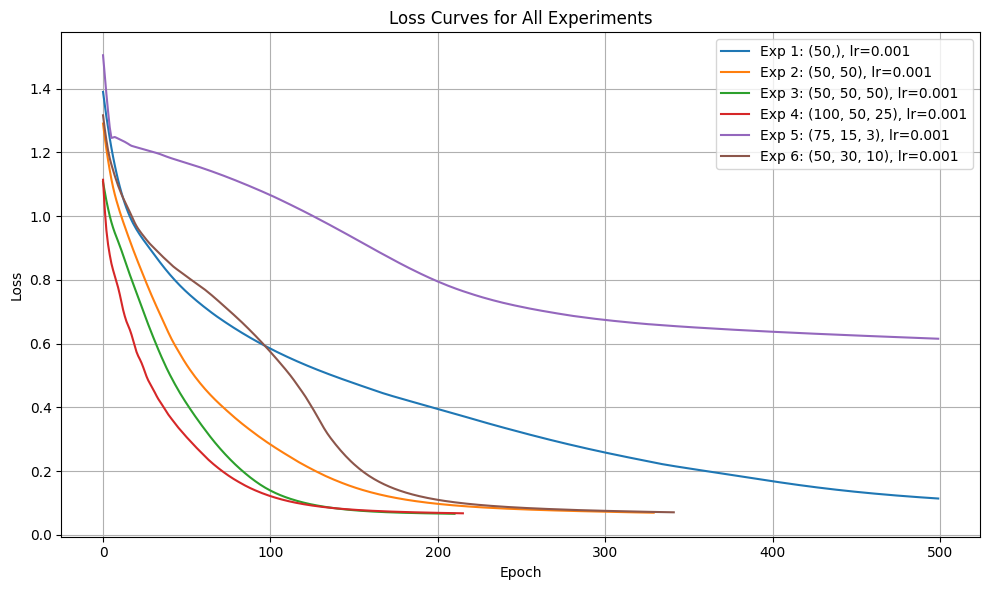

In [15]:
run_user_experiments(X_train, X_test, y_train, y_test)

# Task 02: Change the learning rate of the MLP model and observe its effect on convergence.

How many experiments do you want to run? 4

--- Experiment 1 ---
Enter hidden layer sizes separated by commas (example: 10,10 or 50 or 20,10,5): 100, 50, 25
Enter learning rate (example: 0.001): 0.001
Enter max_iter (press Enter for 500): 500

--- Experiment 2 ---
Enter hidden layer sizes separated by commas (example: 10,10 or 50 or 20,10,5): 100, 50, 25
Enter learning rate (example: 0.001): 0.01
Enter max_iter (press Enter for 500): 500

--- Experiment 3 ---
Enter hidden layer sizes separated by commas (example: 10,10 or 50 or 20,10,5): 50, 50, 50
Enter learning rate (example: 0.001): 0.01
Enter max_iter (press Enter for 500): 500

--- Experiment 4 ---
Enter hidden layer sizes separated by commas (example: 10,10 or 50 or 20,10,5): 50, 50
Enter learning rate (example: 0.001): 0.01
Enter max_iter (press Enter for 500): 500

Experiment Results Table
 Experiment Hidden Layers  Learning Rate  Accuracy  Epochs  Final Loss
          1 (100, 50, 25)          0.001    1.0000     357    0.00575

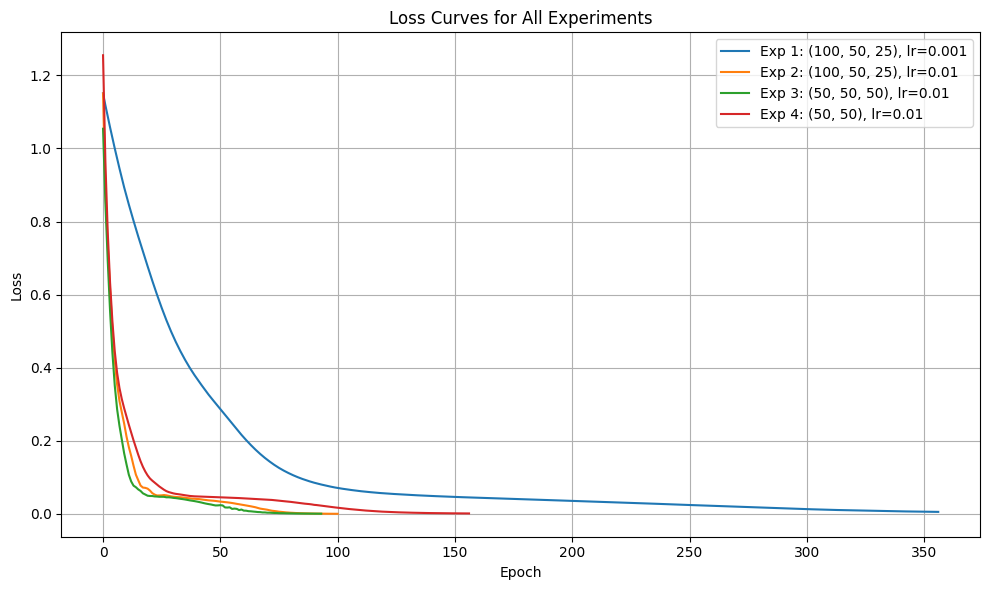

In [8]:
run_user_experiments(X_train, X_test, y_train, y_test)